# Extended-conflict participant (oy): psychometric functions and PSE vs conflict

Single-participant analysis using `data/oyExt_all.csv`, which combines the original main-experiment trials with new extended-conflict trials at ±0.45.

Mirrors the structure of `plotConflictvsPSE.ipynb` but:
- single participant, so per-condition bootstrap is over trials (not participants),
- fits a cumulative-Gaussian PF per (audNoise, conflict) with a custom binomial NLL + `scipy.optimize.minimize` (no `curve_fit`),
- conflicts include ±0.45 and the legend / x-ticks reflect that.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import erf
from scipy.stats import norm

import loadData
import monteCarloClass

# Publication-style figure params (match plotConflictvsPSE.ipynb)
FONT_SIZE_LABEL = 18
FONT_SIZE_TITLE = 20
FONT_SIZE_LEGEND = 20
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': FONT_SIZE_LABEL,
    'axes.titlesize': FONT_SIZE_TITLE,
    'axes.labelsize': FONT_SIZE_LABEL,
    'xtick.labelsize': FONT_SIZE_LABEL,
    'ytick.labelsize': FONT_SIZE_LABEL,
    'legend.fontsize': FONT_SIZE_LEGEND,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

STANDARD_S  = 0.5
STANDARD_MS = 500

## 1. Load data and canonicalise conflicts

Sessions stored conflicts with slight float jitter (e.g. -0.25067 vs -0.25166). Snap each trial's `conflictDur` to its nearest canonical value before grouping.

In [13]:
data, dataName = loadData.loadData('oyExt_all.csv', verbose=False)
print('dataName:', dataName)
print('shape:', data.shape)

CANONICAL_CONFLICTS_S = np.array([-0.45, -0.25, -0.17, -0.08, 0.0, 0.08, 0.17, 0.25, 0.45])

def snap_conflict(c, canonical=CANONICAL_CONFLICTS_S):
    idx = int(np.argmin(np.abs(canonical - c)))
    return float(canonical[idx])

data['conflictDur'] = data['conflictDur'].apply(snap_conflict)
print('conflictDur (ms) after snap:', sorted({int(round(c * 1000)) for c in data['conflictDur'].unique()}))
print('audNoise unique:', sorted(data['audNoise'].unique()))

mc_fitter = monteCarloClass.OmerMonteCarlo(data)
groupedData = mc_fitter.groupByChooseTest(data)
print('grouped rows:', len(groupedData))
groupedData.head()

dataName: oyExt_all
shape: (2773, 59)
conflictDur (ms) after snap: [-450, -250, -170, -80, 0, 80, 170, 250, 450]
audNoise unique: [np.float64(0.1), np.float64(1.2)]
grouped rows: 797


,deltaDurS,audNoise,standardDur,conflictDur,num_of_chose_test,total_responses,num_of_chose_standard,p_choose_test
0,-0.47816,0.1,0.5,-0.25,1,8,7,0.125
1,-0.47816,0.1,0.5,-0.17,1,8,7,0.125
2,-0.47816,0.1,0.5,-0.08,0,3,3,0.000
3,-0.47816,0.1,0.5,0.00,0,7,7,0.000
4,-0.47816,0.1,0.5,0.08,0,6,6,0.000


## 2. Per-condition PF fits (binomial NLL + scipy.minimize)

Cumulative-Gaussian PF: $\Psi(\Delta; \mu, \sigma, \lambda) = \lambda/2 + (1-\lambda)\,\Phi((\Delta-\mu)/\sigma)$.
Binomial NLL:
$$ \mathrm{NLL}(\mu, \sigma, \lambda) = -\sum_\Delta \big[ n_\text{chose}(\Delta)\,\log p_\text{model}(\Delta) + (n_\text{total}-n_\text{chose})(\Delta)\,\log(1-p_\text{model}(\Delta)) \big] $$
Minimised with L-BFGS-B from 4 starts; best result kept.

In [14]:
def cum_gauss(delta, mu, sigma, lam):
    return lam / 2.0 + (1.0 - lam) * norm.cdf(delta, loc=mu, scale=sigma)


def _binom_nll(params, deltas, n_chose, n_total):
    mu, sigma, lam = params
    if sigma <= 0 or lam < 0 or lam > 0.4:
        return 1e10
    p = cum_gauss(deltas, mu, sigma, lam)
    eps = 1e-9
    p = np.clip(p, eps, 1.0 - eps)
    return -float(np.sum(n_chose * np.log(p)
                         + (n_total - n_chose) * np.log(1.0 - p)))


BOUNDS = [(-0.6, 0.6), (1e-3, 1.5), (0.0, 0.4)]
INITS = [
    [0.0,  0.10, 0.02],
    [0.0,  0.05, 0.02],
    [0.05, 0.20, 0.05],
    [-0.05, 0.30, 0.02],
]


def fit_pf(deltas, n_chose, n_total):
    best = None
    for x0 in INITS:
        try:
            res = minimize(_binom_nll, x0, args=(deltas, n_chose, n_total),
                           bounds=BOUNDS, method='L-BFGS-B')
            if res.success and (best is None or res.fun < best.fun):
                best = res
        except Exception:
            continue
    if best is None:
        return np.array([np.nan, np.nan, np.nan]), np.nan
    return best.x, float(best.fun)


def fit_per_condition(grouped):
    rows = []
    for noise in sorted(grouped['audNoise'].unique()):
        for conflict in sorted(grouped['conflictDur'].unique()):
            sub = grouped[(np.isclose(grouped['audNoise'], noise))
                          & (np.isclose(grouped['conflictDur'], conflict))]
            if len(sub) < 3:
                continue
            deltas  = sub['deltaDurS'].values.astype(float)
            n_chose = sub['num_of_chose_test'].values.astype(float)
            n_total = sub['total_responses'].values.astype(float)
            (mu, sigma, lam), nll = fit_pf(deltas, n_chose, n_total)
            rows.append(dict(audNoise=noise, conflict=conflict, mu=mu,
                             sigma=sigma, lam=lam, nll=nll,
                             N=int(n_total.sum())))
    return pd.DataFrame(rows)


fit_df = fit_per_condition(groupedData)
fit_df['conflict_ms'] = (fit_df['conflict'] * 1000).round().astype(int)
fit_df['mu_ms']       = fit_df['mu']    * 1000
fit_df['sigma_ms']    = fit_df['sigma'] * 1000
print(fit_df.round(3).to_string(index=False))

 audNoise  conflict     mu  sigma   lam    nll   N  conflict_ms    mu_ms  sigma_ms
      0.1     -0.45 -0.006  0.277 0.000 82.960 157         -450   -6.485   277.275
      0.1     -0.25  0.067  0.001 0.400 69.193 135         -250   66.980     1.000
      0.1     -0.17  0.016  0.132 0.073 58.287 142         -170   16.195   132.148
      0.1     -0.08  0.038  0.195 0.129 94.018 183          -80   37.777   194.663
      0.1      0.00  0.010  0.228 0.000 84.935 172            0    9.932   228.328
      0.1      0.08  0.076  0.286 0.000 79.783 151           80   76.258   285.574
      0.1      0.17 -0.001  0.237 0.016 78.620 155          170   -0.994   236.593
      0.1      0.25  0.048  0.271 0.000 77.505 147          250   47.917   271.405
      0.1      0.45  0.056  0.251 0.000 70.602 143          450   55.759   251.214
      1.2     -0.45 -0.041  0.231 0.400 95.085 151         -450  -40.554   231.272
      1.2     -0.25 -0.100  0.112 0.344 96.005 175         -250 -100.422   111.562
    

## 3. Trial-bootstrap 95% CIs on PSE

Within each (audNoise, conflict) cell, resample trials with replacement (1000 reps), refit PF, store μ. Percentile 95% CI on μ and σ.

In [15]:
N_BOOT = 50
rng = np.random.default_rng(0)


def bootstrap_condition(trials_df, n_boot=N_BOOT):
    """Bootstrap trials within one (noise, conflict) cell and refit PF.

    Returns arrays of bootstrap mu and sigma values (length n_boot).
    """
    deltas_all = trials_df['deltaDurS'].values.astype(float)
    chose_all  = trials_df['chose_test'].values.astype(float)
    n_trials   = len(trials_df)
    mus, sigmas = np.empty(n_boot), np.empty(n_boot)
    mus[:]    = np.nan
    sigmas[:] = np.nan
    for b in range(n_boot):
        idx = rng.integers(0, n_trials, size=n_trials)
        d_b, c_b = deltas_all[idx], chose_all[idx]
        # Aggregate to per-delta binomial counts before fitting.
        unique_d, inv = np.unique(d_b, return_inverse=True)
        n_total = np.bincount(inv).astype(float)
        n_chose = np.bincount(inv, weights=c_b).astype(float)
        if len(unique_d) < 3:
            continue
        (mu, sigma, _), _ = fit_pf(unique_d, n_chose, n_total)
        mus[b], sigmas[b] = mu, sigma
    return mus, sigmas


boot_rows = []
for noise in sorted(data['audNoise'].unique()):
    for conflict in sorted(data['conflictDur'].unique()):
        sub = data[(np.isclose(data['audNoise'], noise))
                   & (np.isclose(data['conflictDur'], conflict))]
        if len(sub) < 10:
            continue
        mus, sigmas = bootstrap_condition(sub)
        boot_rows.append(dict(
            audNoise=noise, conflict=conflict, conflict_ms=int(round(conflict * 1000)),
            n_trials=len(sub),
            mu_lo=float(np.nanpercentile(mus, 2.5)),
            mu_hi=float(np.nanpercentile(mus, 97.5)),
            mu_med=float(np.nanmedian(mus)),
            sigma_lo=float(np.nanpercentile(sigmas, 2.5)),
            sigma_hi=float(np.nanpercentile(sigmas, 97.5)),
            sigma_med=float(np.nanmedian(sigmas)),
        ))
boot_df = pd.DataFrame(boot_rows)
boot_df['mu_lo_ms'] = boot_df['mu_lo'] * 1000
boot_df['mu_hi_ms'] = boot_df['mu_hi'] * 1000
boot_df['mu_med_ms']= boot_df['mu_med'] * 1000
boot_df['sigma_lo_ms'] = boot_df['sigma_lo'] * 1000
boot_df['sigma_hi_ms'] = boot_df['sigma_hi'] * 1000
boot_df['sigma_med_ms']= boot_df['sigma_med'] * 1000
print(boot_df[['audNoise', 'conflict_ms', 'n_trials', 'mu_med_ms',
               'mu_lo_ms', 'mu_hi_ms', 'sigma_med_ms']].round(1).to_string(index=False))

 audNoise  conflict_ms  n_trials  mu_med_ms  mu_lo_ms  mu_hi_ms  sigma_med_ms
      0.1         -450       157      -11.2     -59.9      63.3         277.4
      0.1         -250       135       21.4     -57.8      96.5          79.4
      0.1         -170       142       13.8     -39.9      51.5         126.9
      0.1          -80       183       41.5      -1.3     116.2         210.5
      0.1            0       172       19.8     -31.7      67.0         229.7
      0.1           80       151       78.1     -17.9     134.0         256.1
      0.1          170       155        1.7     -55.5      52.9         208.2
      0.1          250       147       51.1      -9.1     103.4         265.9
      0.1          450       143       60.4      -1.8     118.9         239.7
      1.2         -450       151      -41.2    -158.8      60.4         288.2
      1.2         -250       175      -97.9    -138.1     -38.1         116.4
      1.2         -170       168      -35.5    -110.8      73.8 

## 4. Psychometric functions per (audNoise, conflict)

Reds = low audio noise (0.1), Blues = high audio noise (1.2). Conflicts coloured light-to-dark within each panel.

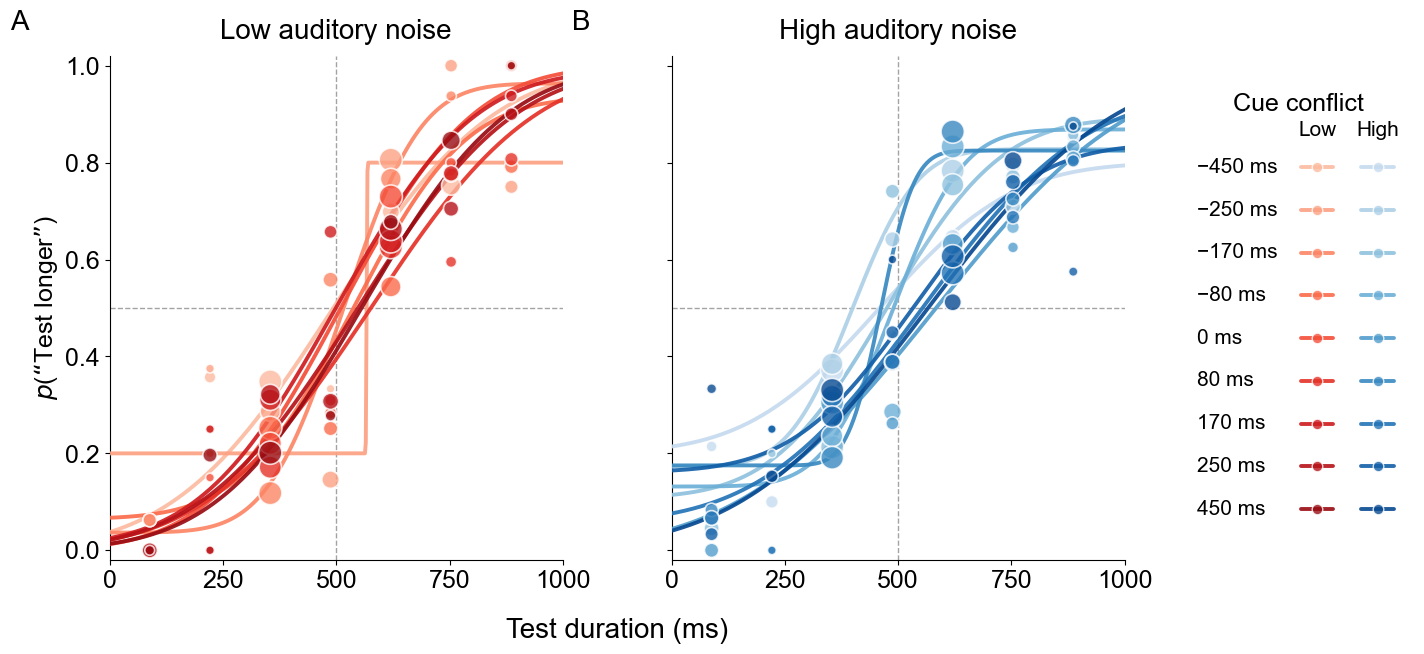

In [16]:
sensory_levels  = sorted(data['audNoise'].unique())
conflict_levels = sorted(data['conflictDur'].unique())

noise_cmaps = {
    sensory_levels[0]: sns.color_palette('Reds', as_cmap=True),
    sensory_levels[1]: sns.color_palette('Blues', as_cmap=True),
}
panel_labels = ['Low auditory noise', 'High auditory noise']
panel_tags = ['A', 'B']

n_conflicts = len(conflict_levels)


def conflict_color(noise, k):
    return noise_cmaps[noise](0.25 + 0.65 * k / max(n_conflicts - 1, 1))


# Shared bin grid in deltaDurS for the binned data points.
intensity = mc_fitter.intensityVar  # 'deltaDurS'
n_bins = 7
global_min = groupedData[intensity].min()
global_max = groupedData[intensity].max()
shared_bin_edges  = np.linspace(global_min, global_max, n_bins + 1)
shared_bin_centres_delta = 0.5 * (shared_bin_edges[:-1] + shared_bin_edges[1:])
shared_bin_centres_ms    = (shared_bin_centres_delta + STANDARD_S) * 1000

fig, axes = plt.subplots(1, 2, figsize=(14.5, 7), sharey=True)

for j, audioNoise in enumerate(sensory_levels):
    ax = axes[j]
    for k, conflict in enumerate(conflict_levels):
        color = conflict_color(audioNoise, k)

        # PF curve from fitted (mu, sigma, lam)
        row = fit_df[(np.isclose(fit_df['audNoise'], audioNoise))
                     & (np.isclose(fit_df['conflict'], conflict))]
        if not row.empty:
            mu = float(row['mu'].iloc[0])
            sigma = float(row['sigma'].iloc[0])
            lam = float(row['lam'].iloc[0])
            x_fine_delta = np.linspace(-0.55, 0.55, 600)
            psi = cum_gauss(x_fine_delta, mu, sigma, lam)
            x_fine_ms = (x_fine_delta + STANDARD_S) * 1000
            ax.plot(x_fine_ms, psi, color=color, linewidth=2.8, alpha=0.92, zorder=3)

        # Binned data points
        subset = groupedData[(np.isclose(groupedData['audNoise'], audioNoise))
                             & (np.isclose(groupedData['conflictDur'], conflict))].copy()
        if subset.empty:
            continue
        subset['bin'] = pd.cut(subset[intensity], bins=shared_bin_edges,
                                labels=False, include_lowest=True)
        binned = subset.groupby('bin').agg(
            y_mean=('p_choose_test', 'mean'),
            total_resp=('total_responses', 'sum'),
        ).dropna()
        if binned.empty:
            continue
        bin_indices = binned.index.astype(int)
        x_ms = shared_bin_centres_ms[bin_indices]
        max_resp, min_resp = binned['total_resp'].max(), binned['total_resp'].min()
        if max_resp > min_resp:
            sizes = 40 + (binned['total_resp'] - min_resp) / (max_resp - min_resp) * 240
        else:
            sizes = 120
        ax.scatter(x_ms, binned['y_mean'], s=sizes, color=color,
                   alpha=0.80, edgecolors='white', linewidths=1.2, zorder=5)

    ax.axhline(0.5, color='#999999', linestyle='--', linewidth=1.0, alpha=0.9)
    ax.axvline(STANDARD_MS, color='#999999', linestyle='--', linewidth=1.0, alpha=0.9)
    ax.set_xlim(0, 1000)
    ax.set_xticks([0, 250, 500, 750, 1000])
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(panel_labels[j], fontsize=FONT_SIZE_TITLE, loc='center', pad=12)
    ax.text(-0.22, 1.04, panel_tags[j], transform=ax.transAxes,
            ha='left', va='bottom', fontsize=FONT_SIZE_TITLE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE_LABEL)

axes[0].set_ylabel('$p$(“Test longer”)', fontsize=FONT_SIZE_LABEL)

# Right-side legend keyed by conflict, with both noise tints
def _fmt_ms(ms_int):
    return f'\u2212{abs(ms_int)} ms' if ms_int < 0 else f'{ms_int} ms'

legend_ax = fig.add_axes([0.82, 0.18, 0.16, 0.66])
legend_ax.set_xlim(0, 1); legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([]); legend_ax.set_yticks([])
for spine in legend_ax.spines.values():
    spine.set_visible(False)
legend_ax.text(0.5, 0.98, 'Cue conflict', ha='center', va='top',
               fontsize=FONT_SIZE_LEGEND - 2)
legend_ax.text(0.58, 0.90, 'Low', ha='center', va='center', fontsize=FONT_SIZE_LEGEND - 5)
legend_ax.text(0.84, 0.90, 'High', ha='center', va='center', fontsize=FONT_SIZE_LEGEND - 5)
y_positions = np.linspace(0.82, 0.08, len(conflict_levels))
for y_pos, conflict in zip(y_positions, conflict_levels):
    k = conflict_levels.index(conflict)
    ms = int(round(conflict * 1000))
    legend_ax.text(0.06, y_pos, _fmt_ms(ms), ha='left', va='center',
                   fontsize=FONT_SIZE_LEGEND - 5)
    for x_pos, audioNoise in zip([0.58, 0.84], sensory_levels):
        color = conflict_color(audioNoise, k)
        legend_ax.plot([x_pos - 0.07, x_pos + 0.07], [y_pos, y_pos],
                       color=color, linewidth=2.8, alpha=0.9, solid_capstyle='round')
        legend_ax.scatter([x_pos], [y_pos], s=58, color=color, alpha=0.80,
                          edgecolors='white', linewidths=1.0, zorder=3)

fig.supxlabel('Test duration (ms)', fontsize=FONT_SIZE_LABEL + 2, x=0.43, y=0.04)
fig.subplots_adjust(left=0.08, right=0.78, bottom=0.16, top=0.88, wspace=0.24)
fig.savefig('oyExt_psychometric_functions.pdf', dpi=600, bbox_inches='tight')
fig.savefig('oyExt_psychometric_functions.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. PSE vs conflict (with trial-bootstrap 95% CI)

PSE shift (mean of bootstrap distribution on μ) and 95% percentile CI from the trial-resample bootstrap above. Light grey dotted line is the complete-visual-capture prediction (PSE = conflict).

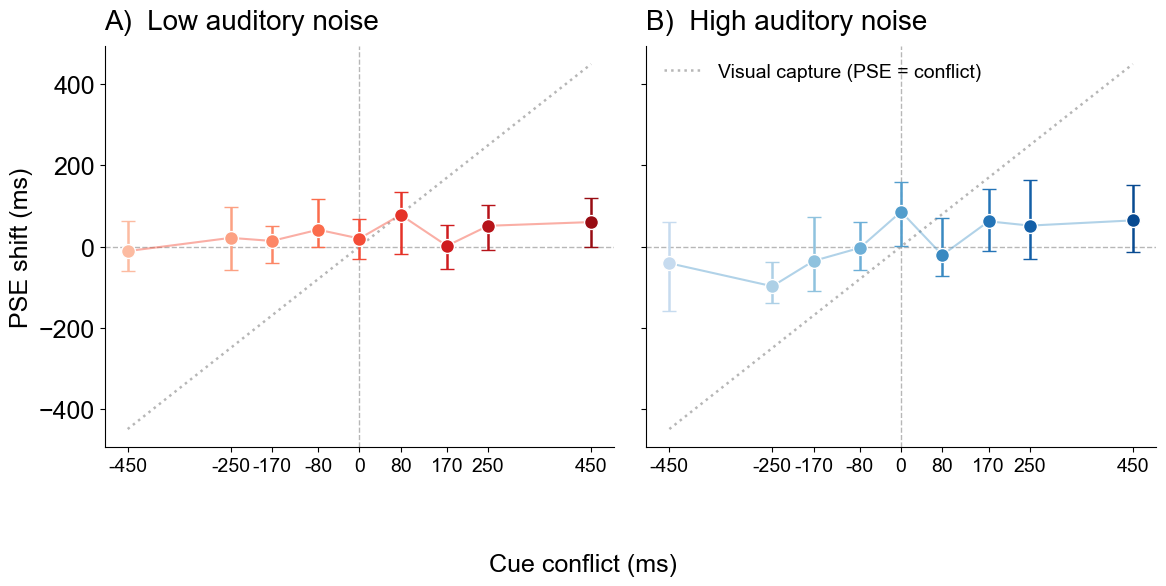

In [17]:
noise_vals = sorted(boot_df['audNoise'].unique())
noise_labels = {noise_vals[0]: 'Low auditory noise',
                noise_vals[1]: 'High auditory noise'}
noise_cmaps_pse = {
    noise_vals[0]: sns.color_palette('Reds', as_cmap=True),
    noise_vals[1]: sns.color_palette('Blues', as_cmap=True),
}
conflict_ticks_ms = sorted(boot_df['conflict_ms'].unique())
n_conflict_levels = len(conflict_ticks_ms)


def conflict_color_pse(noise_val, k, n_total):
    return noise_cmaps_pse[noise_val](0.25 + 0.65 * k / max(n_total - 1, 1))


fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
panel_prefix = ['A)', 'B)']
for idx, noise_val in enumerate(noise_vals):
    ax  = axes[idx]
    sub = boot_df[boot_df['audNoise'] == noise_val].sort_values('conflict_ms')
    for k, (_, row) in enumerate(sub.iterrows()):
        color = conflict_color_pse(noise_val, k, n_conflict_levels)
        y     = row['mu_med_ms']
        ylo, yhi = row['mu_lo_ms'], row['mu_hi_ms']
        ax.errorbar(row['conflict_ms'], y,
                    yerr=[[y - ylo], [yhi - y]],
                    fmt='o', color=color, capsize=5, markersize=10,
                    linewidth=1.8, capthick=1.5,
                    markerfacecolor=color, markeredgecolor='white',
                    markeredgewidth=1.0, zorder=5)
    mid_color = conflict_color_pse(noise_val, n_conflict_levels // 2, n_conflict_levels)
    ax.plot(sub['conflict_ms'], sub['mu_med_ms'],
            color=mid_color, linewidth=1.5, alpha=0.45, zorder=3)
    # Reference lines
    ax.axhline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.axvline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    conflict_range = np.array(sorted(sub['conflict_ms']))
    ax.plot(conflict_range, conflict_range, color='#aaaaaa', linestyle=':',
            linewidth=1.8, alpha=0.85, zorder=2,
            label='Visual capture (PSE = conflict)' if idx == 1 else None)
    ax.set_title(f'{panel_prefix[idx]}  {noise_labels[noise_val]}',
                 fontsize=FONT_SIZE_TITLE, loc='left', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE_LABEL)
    ax.set_xticks(conflict_ticks_ms)
    ax.set_xticklabels([str(t) for t in conflict_ticks_ms],
                       fontsize=FONT_SIZE_LABEL - 4, rotation=0)
axes[0].set_ylabel('PSE shift (ms)', fontsize=FONT_SIZE_LABEL)
axes[1].legend(fontsize=FONT_SIZE_LEGEND - 6, frameon=False, loc='upper left')
fig.supxlabel('Cue conflict (ms)', fontsize=FONT_SIZE_LABEL, x=0.5)
plt.tight_layout(rect=(0, 0.05, 1.0, 1))
fig.savefig('oyExt_pse_vs_conflict.pdf', dpi=600, bbox_inches='tight')
fig.savefig('oyExt_pse_vs_conflict.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. PF σ vs conflict (bonus)

Same conditions, PF width σ instead of PSE. Useful for checking whether extending conflict to ±0.45 actually changes the slope structure predicted by the CI / switching models.

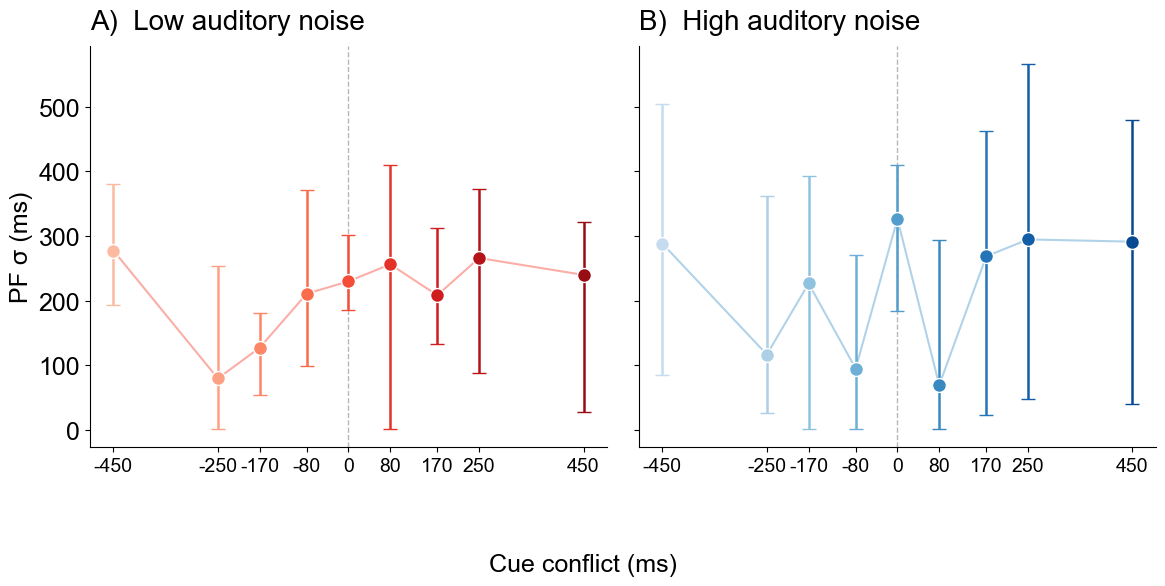

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for idx, noise_val in enumerate(noise_vals):
    ax  = axes[idx]
    sub = boot_df[boot_df['audNoise'] == noise_val].sort_values('conflict_ms')
    for k, (_, row) in enumerate(sub.iterrows()):
        color = conflict_color_pse(noise_val, k, n_conflict_levels)
        y     = row['sigma_med_ms']
        ylo, yhi = row['sigma_lo_ms'], row['sigma_hi_ms']
        ax.errorbar(row['conflict_ms'], y,
                    yerr=[[y - ylo], [yhi - y]],
                    fmt='o', color=color, capsize=5, markersize=10,
                    linewidth=1.8, capthick=1.5,
                    markerfacecolor=color, markeredgecolor='white',
                    markeredgewidth=1.0, zorder=5)
    mid_color = conflict_color_pse(noise_val, n_conflict_levels // 2, n_conflict_levels)
    ax.plot(sub['conflict_ms'], sub['sigma_med_ms'],
            color=mid_color, linewidth=1.5, alpha=0.45, zorder=3)
    ax.axvline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.set_title(f'{panel_prefix[idx]}  {noise_labels[noise_val]}',
                 fontsize=FONT_SIZE_TITLE, loc='left', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE_LABEL)
    ax.set_xticks(conflict_ticks_ms)
    ax.set_xticklabels([str(t) for t in conflict_ticks_ms],
                       fontsize=FONT_SIZE_LABEL - 4, rotation=0)
axes[0].set_ylabel('PF σ (ms)', fontsize=FONT_SIZE_LABEL)
fig.supxlabel('Cue conflict (ms)', fontsize=FONT_SIZE_LABEL, x=0.5)
plt.tight_layout(rect=(0, 0.05, 1.0, 1))
fig.savefig('oyExt_sigma_vs_conflict.pdf', dpi=600, bbox_inches='tight')
fig.savefig('oyExt_sigma_vs_conflict.png', dpi=300, bbox_inches='tight')
plt.show()

## Files produced

- `oyExt_psychometric_functions.{pdf,png}` — two-panel PFs (low / high audio noise) with conflicts colour-coded
- `oyExt_pse_vs_conflict.{pdf,png}` — PSE vs conflict with trial-bootstrap 95% CI
- `oyExt_sigma_vs_conflict.{pdf,png}` — PF σ vs conflict with trial-bootstrap 95% CI